<a href="https://colab.research.google.com/github/NayshaM/STAT-7110-Quality-Control/blob/Assignment-1/STAT_7110_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 1 - Phase I & II Analysis Using Shewhart $\bar{X}$ and R/s Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: September 19, 2026 via D2L**

## Instructions:

A company called Blue Ridge Filament Co (BRFC) manufactures 1.75 mm PLA filament for 3D printers, selling to both hobbyist and small-manufacturing customers. Over the last quarter, customer support tickets describing clogging, stringing, and inconsistent print layers have risen sharply, and BRFC recently lost a wholesale account to a competitor over “inconsistent quality.” The plant manager has asked your quality control team to investigate Extruder Line 3, the line most frequently named in the complaint data, and to determine whether the line is running in a state of statistical control. This line is about six months away from needing its heating element replaced, but it could be replaced sooner if necessary.

The plant manager is particularly interested in the filament diameter produced (mm), measured inline by a laser micrometer as each spool is produced. Diameter that runs too thin causes under-extrusion and stringing; diameter that runs too thick causes jams and clogs in customers' print heads. Filament diameter is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of production data from Line 3: 5 spools sampled at random each week, for 25 consecutive weeks. After validating statistical control and process capability, the team can establish an ongoing monitoring plan for Phase II analysis.

## Key Specifications

| Quantity | Value |
|---|---|
| Target diameter | 1.750 mm |
| Lower Specification Limit (LSL) | 1.700 mm |
| Upper Specification Limit (USL) | 1.800 mm |
| Subgroup size (n) | 5 spools per week |
| Phase I subgroups (m) | 25 weeks |
| Phase II subgroups | 20 weeks |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

# The purpose of this analysis is to investigate Extruder Line 3 and to determine whether the line is running in a state of statistical control.

### Q2: Identify the quality characteristic your team will monitor, classify its units and measurement scale.

# The quality characteristic the team will monitor is the filament diameter produced by Extruder Line 3. Its units are mm and the mesaurement scale is a ratio scale.

# Q3: Briefly describe why a Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario. What are its limitations?

# A Shewhart $\bar{X}$ and $R/s$ chart would be appropriate in this scenario because the data is treated as a continuous, normally-distributed quality characteristic. The limitations are that it assumes a normal distribution which may not always be true.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the estimated process mean and standard deviation using both the $R$ and $s$ methods.


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


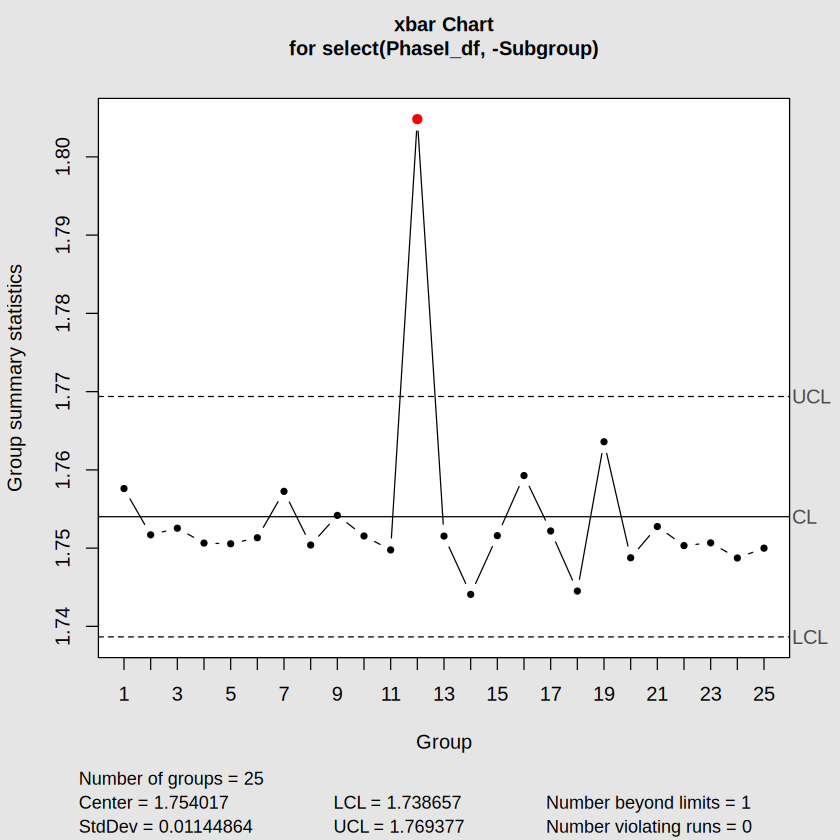

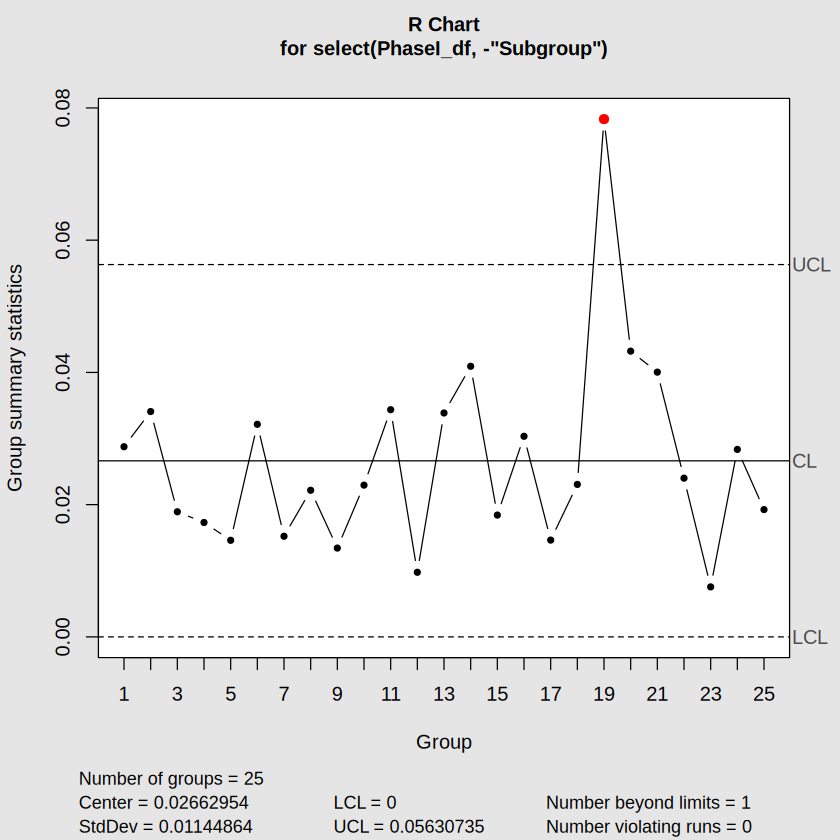

List of 11
 $ call      : language qcc(data = PhaseI_df[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "PhaseI_df[, -1]"
 $ data      : num [1:25, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.01029 0.01349 0.00788 0.00719 0.00635 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0109
 $ std.dev   : num 0.0115
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0227
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

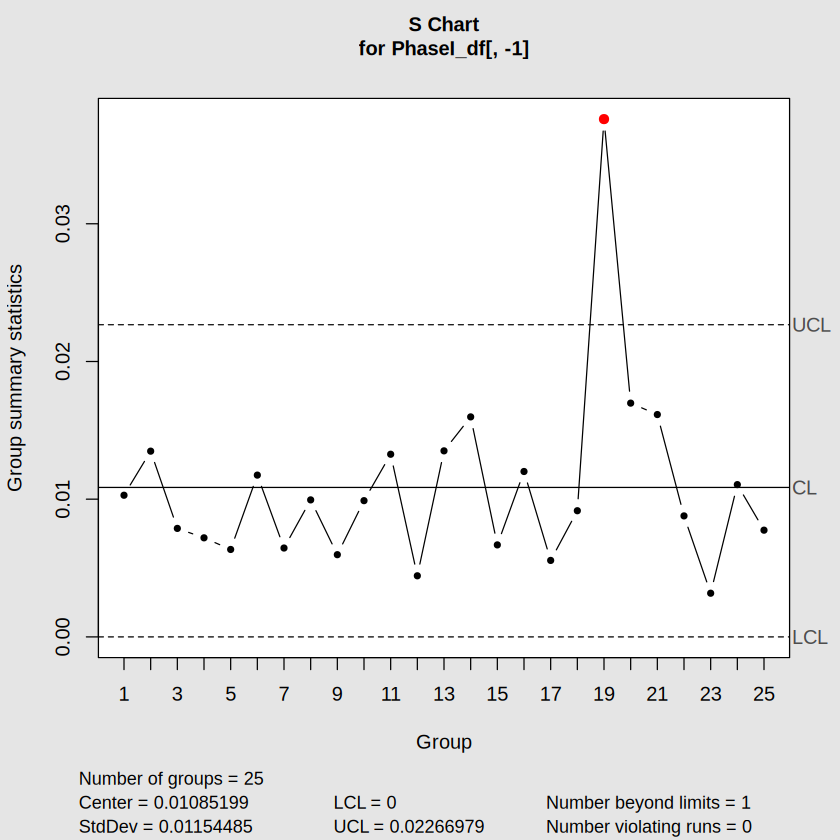

In [1]:
## Q4 Code ##
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "NayshaM"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

## Set working directory to /content/ where the repository was cloned
setwd("/content/STAT-7110-Quality-Control/Assignments/HW1")

## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Filament Data ##

PhaseI_df <- read_excel("FilamentDiameter_PhaseI.xlsx")


## Data Integrity Check ##

PhaseI_df |>
  glimpse()

## Phase 1 X Chart ##

PhaseI_X_Chart <- qcc(PhaseI_df |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)

## Phase 1 R Chart ##

PhaseI_R <- qcc(PhaseI_df |> select (-'Subgroup'),
                type = "R",
                plot = TRUE)

## Phase 1 S Chart ##

qcc(PhaseI_df[,-1], type = "S", plot = TRUE)

# The estimated process mean and standard deviation is 1.754 and .011 respectively.


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

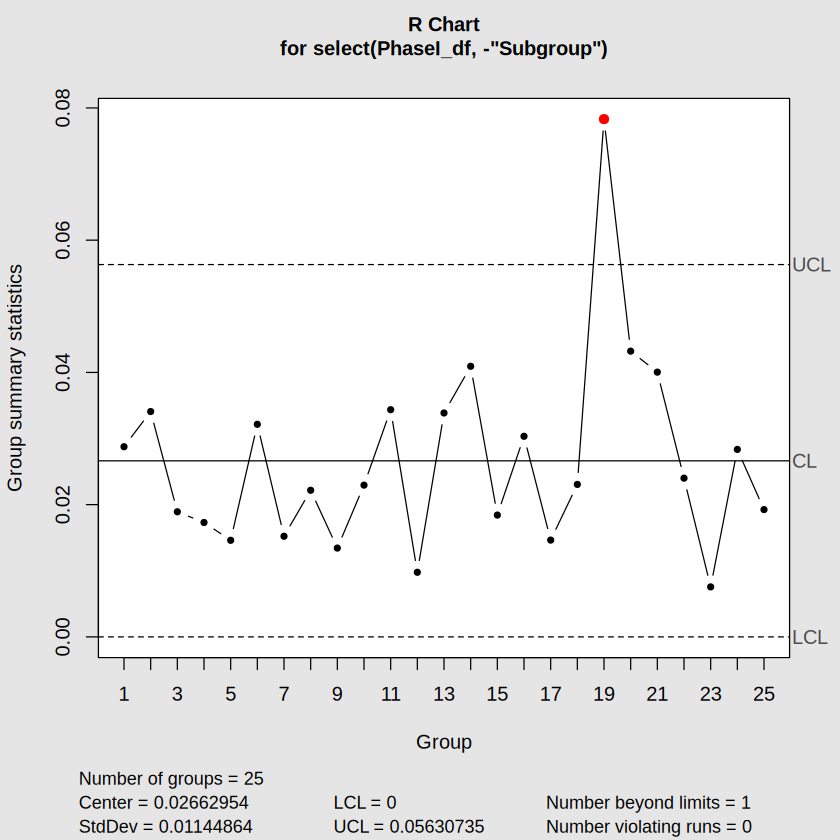

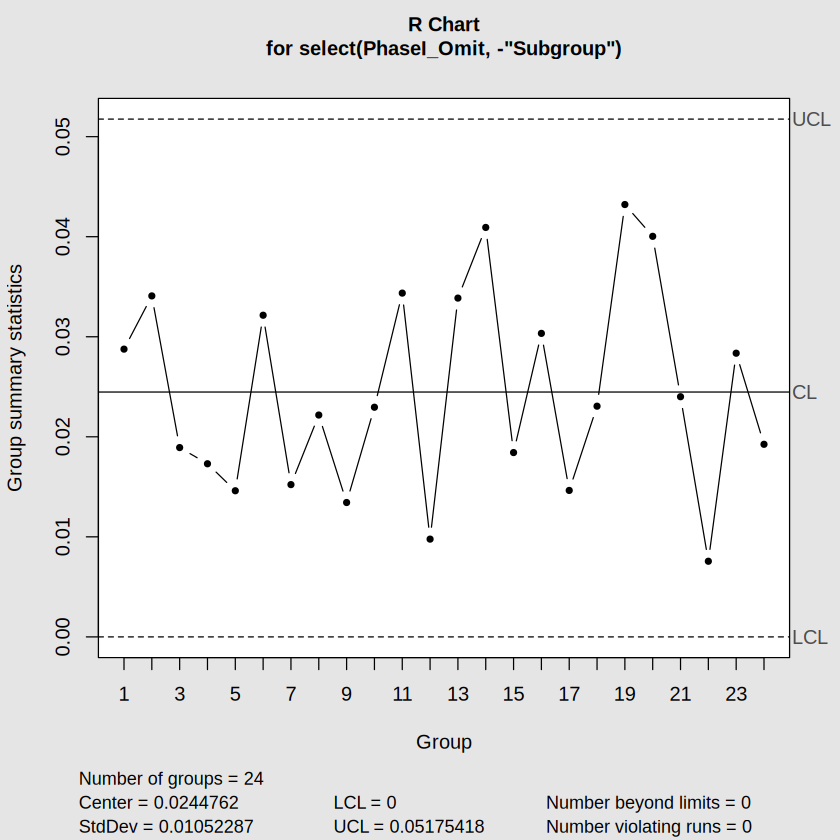

In [2]:
## Q5 Code ##

PhaseI_R_Chart <- qcc(PhaseI_df |> select (-'Subgroup'),
                type = "R",
                plot = TRUE)

PhaseI_Omit <- PhaseI_df |>
  filter(Subgroup != 19)

PhaseI_X_Omit_Chart <- qcc(PhaseI_Omit |> select (-'Subgroup'),
                    type = "R",
                    plot = TRUE)


# The chart does not show evidence of statistical control due to subgroup 19 that is beyond limits. These ooc points may have been observed because the replacement window during that time was closer.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

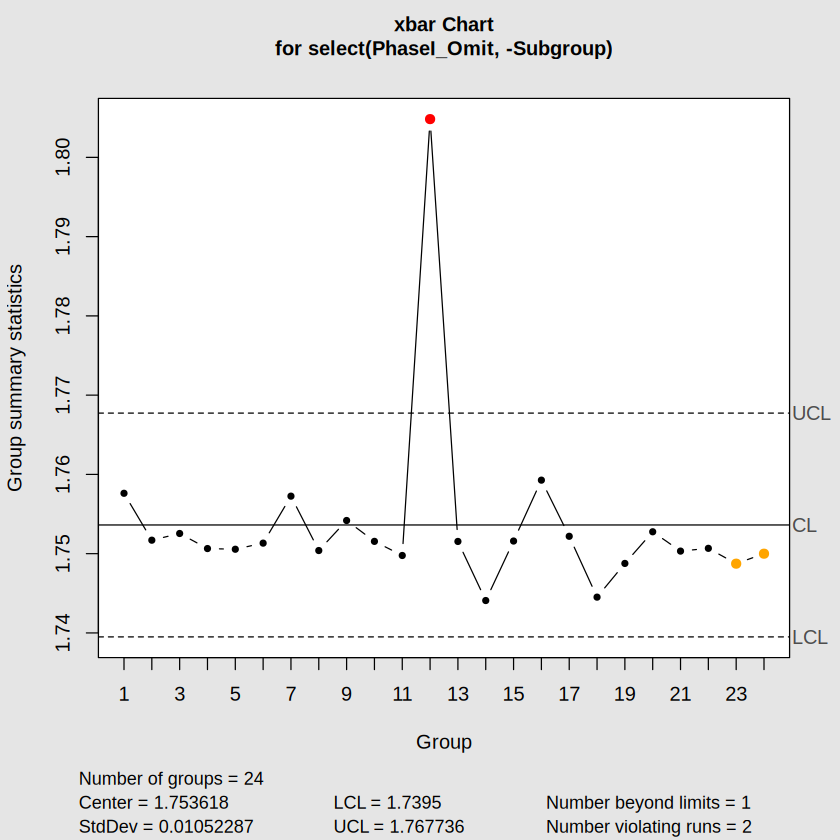

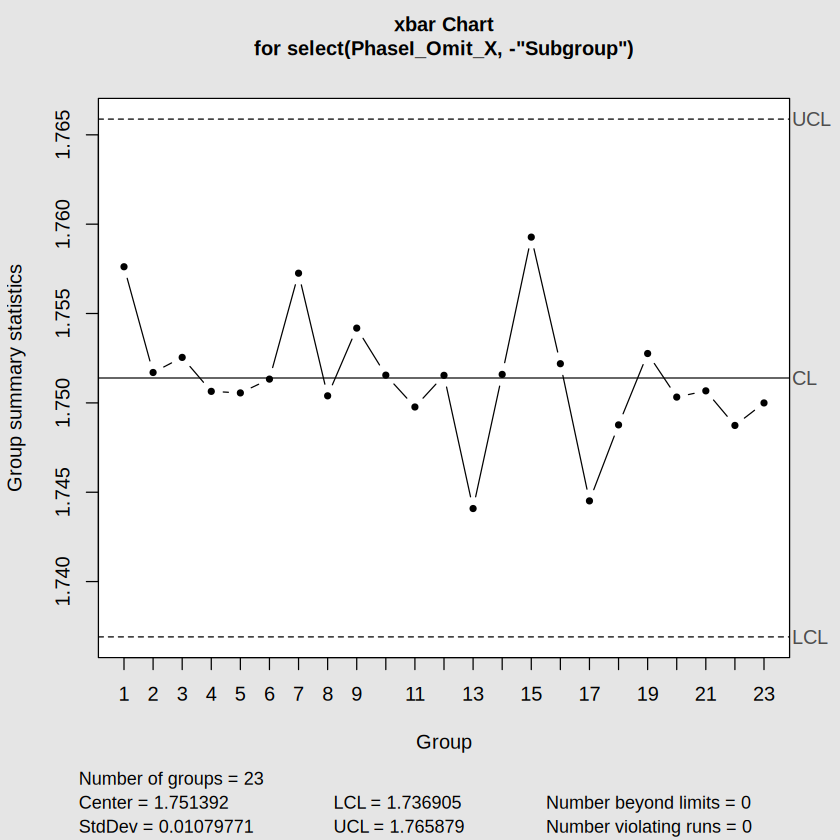

In [3]:
## Q6 Code ##

PhaseI_X_Chart2 <- qcc(PhaseI_Omit |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)

PhaseI_Omit_X <- PhaseI_Omit |>
  filter(Subgroup != 12)

PhaseI_X_Chart_Omit <- qcc(PhaseI_Omit_X |> select(-'Subgroup'),
                         type = "xbar",
                         plot = TRUE)

# The chart does not show evidence of statistical control due to subgroup 12 being beyond the upper limit. These ooc points may have been observed due to a change in temperature that caused an increase thinkness in diameter causing jams.

### Q7: Repeat the same process in Q4 - Q6 now using the $s$ chart instead of the $R$ chart

Rows: 25
Columns: 6
$ Subgroup <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18…
$ Meas1    <dbl> 1.759712, 1.752064, 1.755094, 1.763434, 1.751915, 1.746336, 1…
$ Meas2    <dbl> 1.742690, 1.733264, 1.745186, 1.746130, 1.757228, 1.769405, 1…
$ Meas3    <dbl> 1.771452, 1.767347, 1.753372, 1.747787, 1.745419, 1.752795, 1…
$ Meas4    <dbl> 1.758564, 1.761277, 1.763998, 1.747608, 1.755608, 1.750858, 1…
$ Meas5    <dbl> 1.755669, 1.744550, 1.745075, 1.748262, 1.742620, 1.737254, 1…


List of 11
 $ call      : language qcc(data = PhaseI_df[, -1], type = "xbar", std.dev = sig_hat, plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "PhaseI_df[, -1]"
 $ data      : num [1:25, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 1.76 1.75 1.75 1.75 1.75 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 1.75
 $ std.dev   : num 0.0114
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 1.74 1.77
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

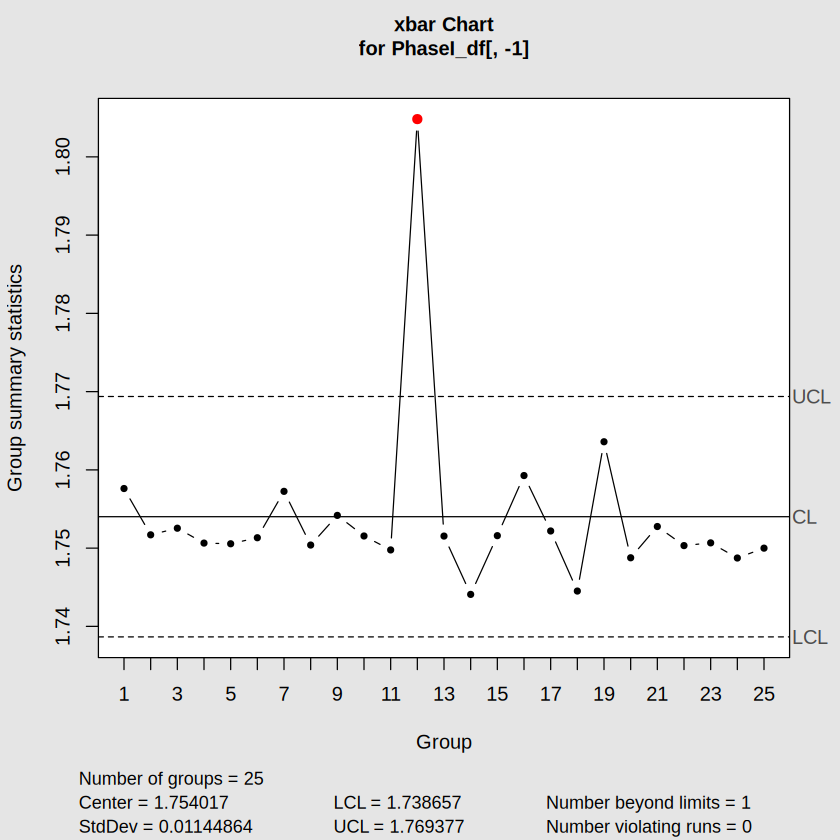

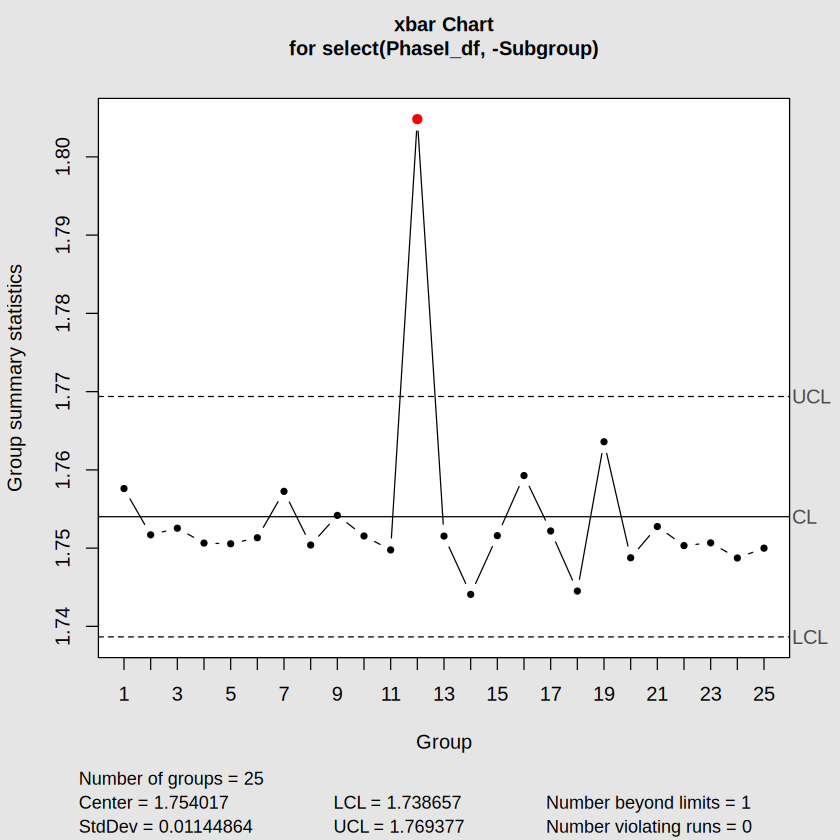

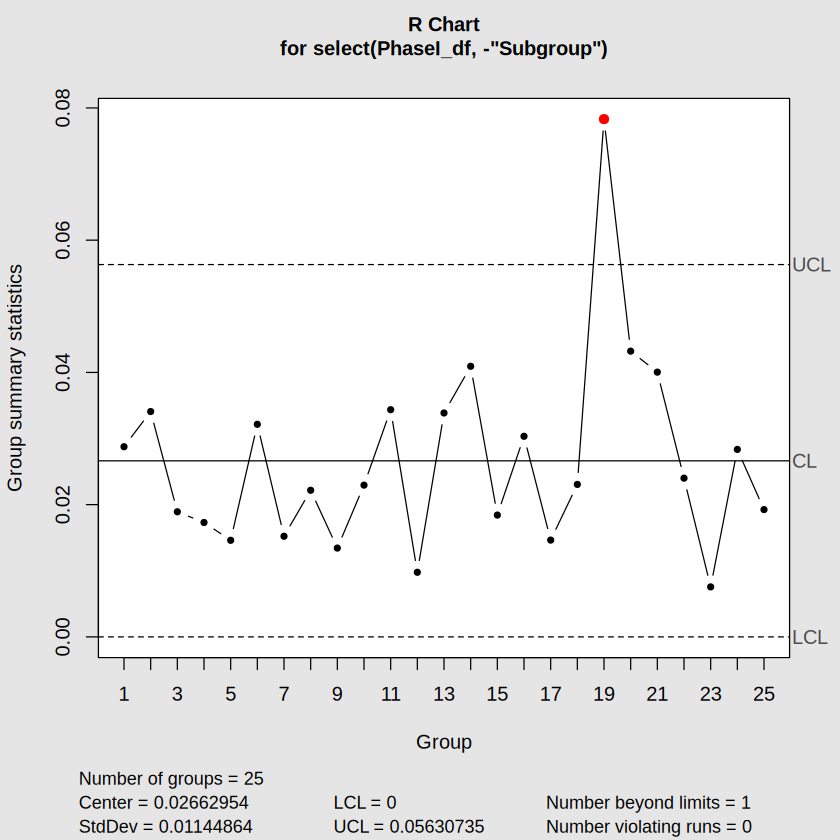

List of 11
 $ call      : language qcc(data = PhaseI_df[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "PhaseI_df[, -1]"
 $ data      : num [1:25, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.01029 0.01349 0.00788 0.00719 0.00635 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0109
 $ std.dev   : num 0.0115
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0227
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

List of 11
 $ call      : language qcc(data = PhaseI_df[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "PhaseI_df[, -1]"
 $ data      : num [1:25, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:25] 0.01029 0.01349 0.00788 0.00719 0.00635 ...
  ..- attr(*, "names")= chr [1:25] "1" "2" "3" "4" ...
 $ sizes     : int [1:25] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.0109
 $ std.dev   : num 0.0115
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0227
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

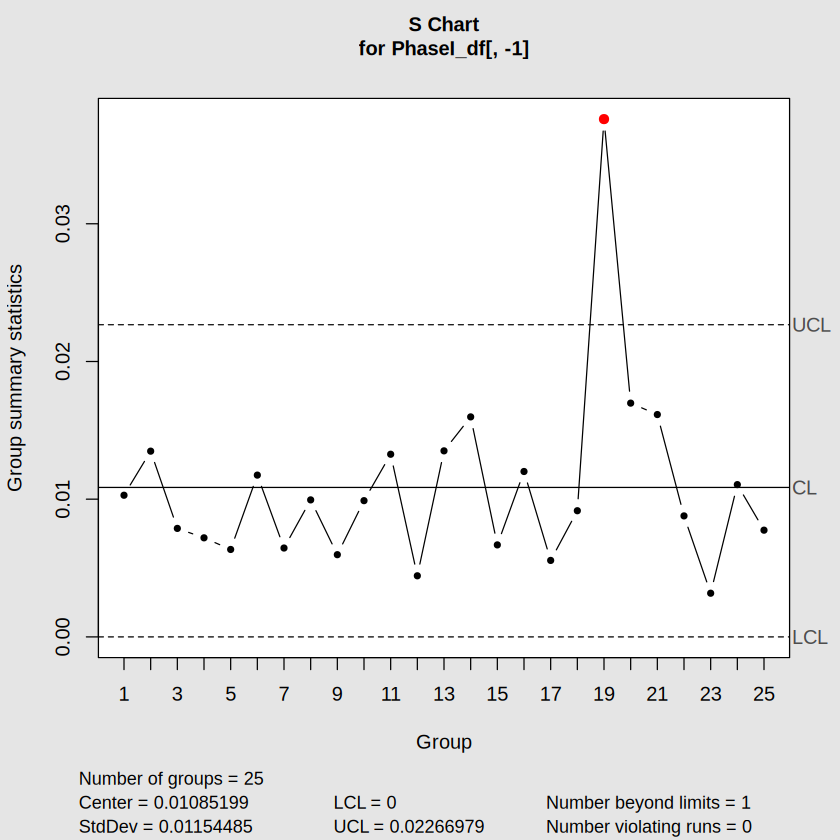

List of 11
 $ call      : language qcc(data = PhaseI_Omit_S[, -1], type = "S", plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "PhaseI_Omit_S[, -1]"
 $ data      : num [1:24, 1:5] 1.76 1.75 1.76 1.76 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 0.01029 0.01349 0.00788 0.00719 0.00635 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.00974
 $ std.dev   : num 0.0104
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0203
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

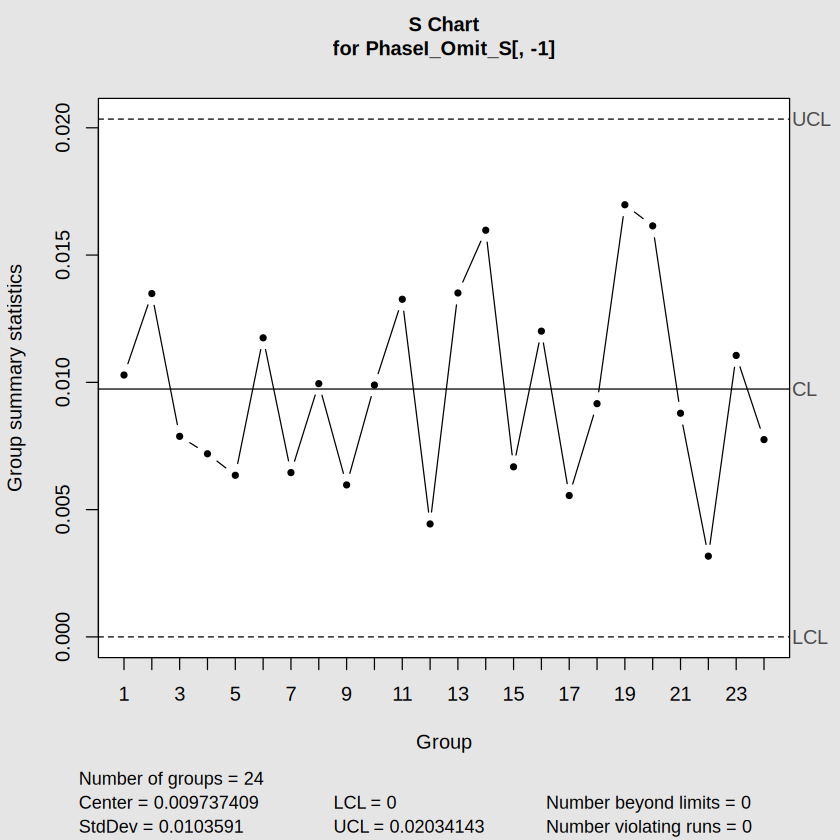

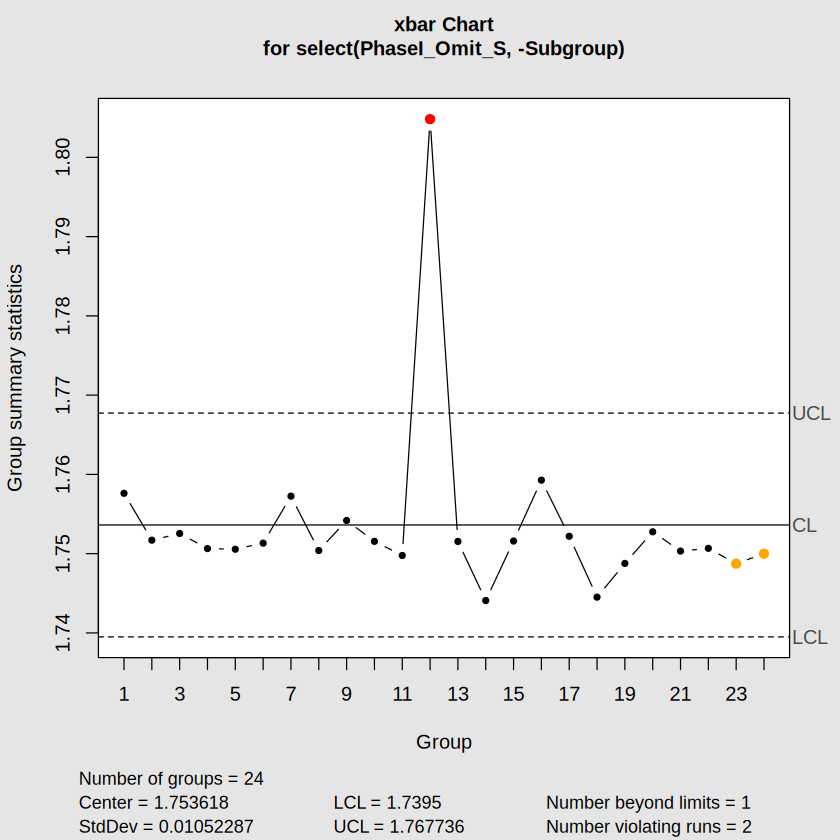

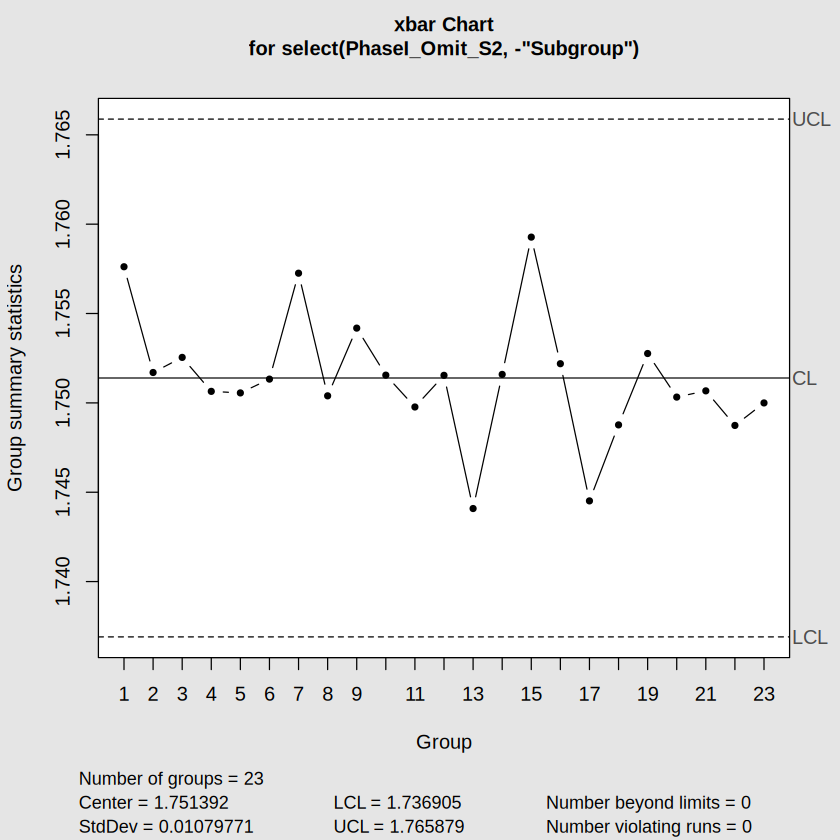

In [5]:
## Q7 Code ##

#Q4#
## Data Integrity Check ##

PhaseI_df |>
  glimpse()

## Phase 1 X Chart ##

sig_hat <- sd.xbar(PhaseI_df[,-1]) # This gives us s-bar/c4

qcc(PhaseI_df[,-1],type="xbar",std.dev=sig_hat,plot=TRUE)


PhaseI_X_Chart <- qcc(PhaseI_df |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)

## Phase 1 R Chart ##

PhaseI_R <- qcc(PhaseI_df |> select (-'Subgroup'),
                type = "R",
                plot = TRUE)

## Phase 1 S Chart ##


qcc(PhaseI_df[,-1], type = "S", plot = TRUE)

#Q5#

qcc(PhaseI_df[,-1], type = "S", plot = TRUE)

PhaseI_Omit_S <- PhaseI_df |>
  filter(Subgroup != 19)

qcc(PhaseI_Omit_S[,-1], type = "S", plot = TRUE)


#Q6#

PhaseI_X_Chart3 <- qcc(PhaseI_Omit_S |> select(-`Subgroup`),
                   type = "xbar",
                   plot = TRUE)

PhaseI_Omit_S2 <- PhaseI_Omit_S |>
  filter(Subgroup != 12)

PhaseI_Omit_X_Chart4 <- qcc(PhaseI_Omit_S2|> select(-'Subgroup'),
                         type = "xbar",
                         plot = TRUE)

# The estimated mean and process standard deviation is 1.754 and .001 respectively.

# The Phase 1 S chart does not show evidence of statistical control due to subgroup 19 being beyond the upper limit. These ooc points can be caused because it was closer to the replacement time.

# The X chart does not show evidence of statistical control due to subgroup 12 being beyond the upper limit. This is again, another ooc group that had too thick of a diameter which was causing clogging.

### Q8: Using your final Phase I estimates of the process mean and process standard deviation (using $s$ method), perform a process capability analysis against the specification limits given about. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?


Process Capability Analysis

Call:
process.capability(object = PhaseI_Omit_X_Chart4, spec.limits = c(1.7,     1.8), target = 1.75, nsigmas = 3)

Number of obs = 115          Target = 1.75
       Center = 1.751           LSL = 1.7
       StdDev = 0.0108          USL = 1.8

Capability indices:

      Value   2.5%  97.5%
Cp    1.544  1.343  1.743
Cp_l  1.587  1.406  1.767
Cp_u  1.501  1.329  1.672
Cp_k  1.501  1.296  1.705
Cpm   1.531  1.332  1.730

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 0%	 Obs>USL 0%


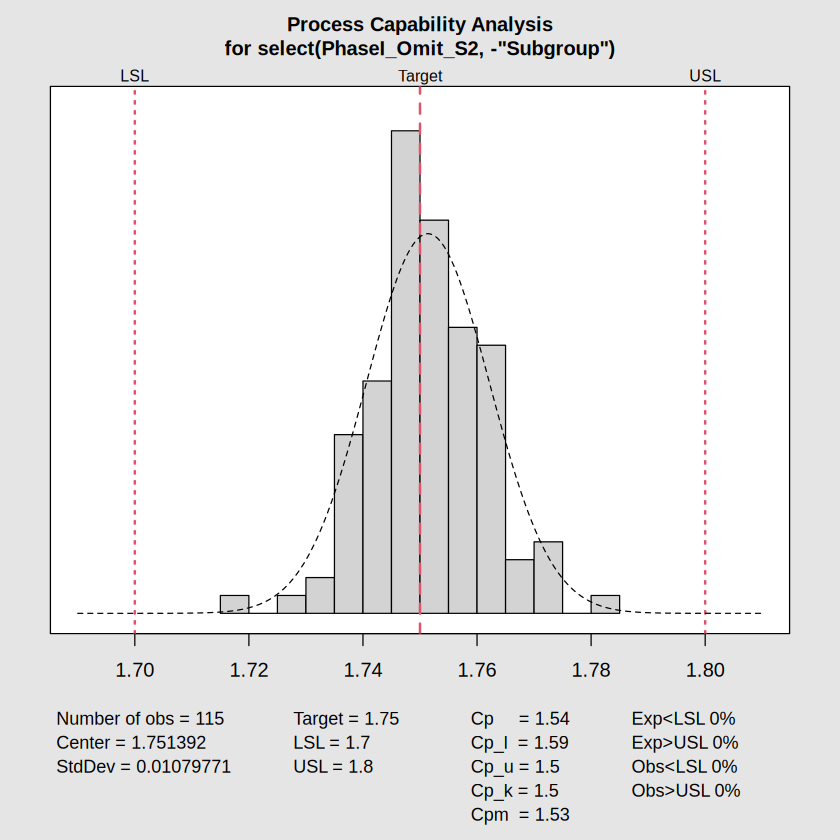

In [6]:
## Q8 Code ##

process.capability(PhaseI_Omit_X_Chart4,spec.limits=c(1.700,1.800),target=1.75,nsigmas=3)


## FNC

## From the chart, Exp<LSL + Exp>USL = 0% = 0.0004. This is good. This means that everthting is expected to be on target.

## CP

## Cp = 1.54, which means that the difference between USL & LSL is 1.54 times the difference between UCL & LCL. This is good. A CP greater than 1 means there is a small process variation.


## CPK

## From the chart, we can see that Cpk is 1.5, which is good. This is close to our CP meaning we see centered data and since it's greater than 1 we see less variability.

## CPM

## CPM is 1.53, which is also good because its > 1. This mmeasure accounts for the process's centering.

## Since all measures are above 1, the process is capable of meeting specifications and is well-centered.

## Improve

### Q9: Briefly provide a contextual explanation as to leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable.

# Leaving OOC points in the Phase I calculation of the control limits after identifying an assignable cause is not advisable because those points are not part of the normal process. This means that it will affect the results and could make them inaccurate. In the current example, temperature issues, past replacement filaments, and other conditions that are out of the norm creates less reliable estimates.

## Control

### Q10: Read in the Phase II data into R. Using the finalized Phase I center line and control limits from Q7, construct the Phase II $\bar{X}$ chart. Do any subgroups plot outside the control limits?

X-Bar Limits
      LCL      UCL
 1.736032 1.766752
S-Chart Limits
 LCL        UCL
   0 0.02082286


List of 11
 $ call      : language qcc(data = Phase2_df[, -1], type = "xbar", center = Phase2_center_x, limits = Phase2_lims,      plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "Phase2_df[, -1]"
 $ data      : num [1:20, 1:5] 1.74 1.75 1.76 1.75 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 1.75 1.75 1.75 1.75 1.75 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 1.75
 $ std.dev   : num 0.00606
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 1.74 1.77
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

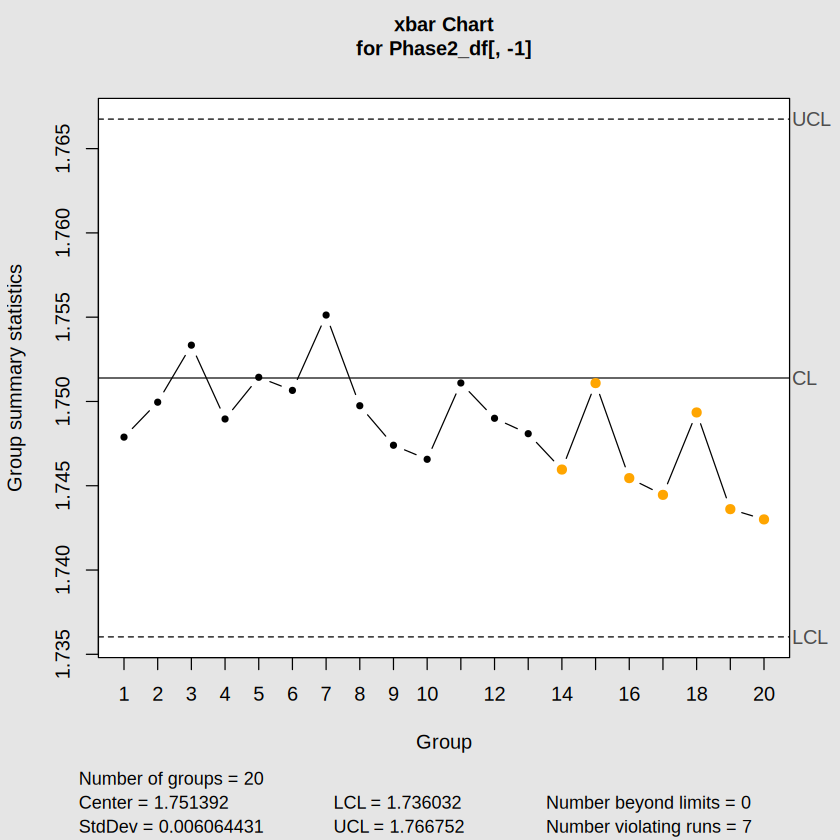

In [8]:
## Q10 Code ##

## Read in Phase II data ##

Phase2_df <- read_xlsx("FilamentDiameter_PhaseII.xlsx")

## Save the Phase I limits and center values ##

## Limits ##

Phase2_lims <- qcc(PhaseI_Omit_S2[,-1],type="xbar",std.dev=sig_hat,plot=FALSE)$limits

Phase2_s_lims <- qcc(PhaseI_Omit_S2[,-1],type="S",plot=FALSE)$limits

## Center Values ##

Phase2_center_x <- qcc(PhaseI_Omit_S2[,-1],type="xbar",std.dev=sig_hat,plot=FALSE)$center

Phase2_center_s <- qcc(PhaseI_Omit_S2[,-1],type="S",plot=FALSE)$center

cat("X-Bar Limits\n")
print(Phase2_lims)
cat("S-Chart Limits\n")
print(Phase2_s_lims)

## Phase II X-bar ##

qcc(Phase2_df[,-1],type="xbar",center=Phase2_center_x,limits=Phase2_lims,plot=TRUE)


# There are no subgroups plotting outside the control limits.

### Q11: Construct a Phase II $s$ chart. Do any subgroups plot outside the control limits?

List of 11
 $ call      : language qcc(data = Phase2_df[, -1], type = "S", center = Phase2_center_s, limits = Phase2_s_lims,      plot = TRUE)
 $ type      : chr "S"
 $ data.name : chr "Phase2_df[, -1]"
 $ data      : num [1:20, 1:5] 1.74 1.75 1.76 1.75 1.75 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 0.00989 0.00292 0.00445 0.00625 0.00177 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.00997
 $ std.dev   : num 0.00625
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.0208
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

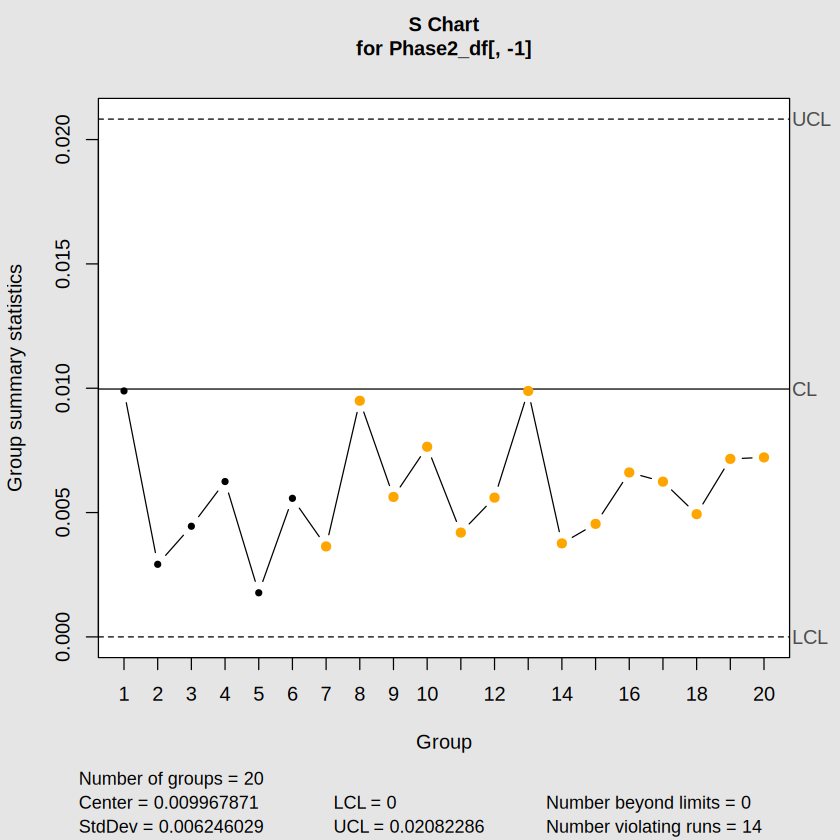

In [9]:
## Q11 Code ##

## Phase II S ##

qcc(Phase2_df[,-1],type="S",center=Phase2_center_s,limits=Phase2_s_lims,plot=TRUE)

# There are no subgroups plotting outside the control limits.

### Q12: Provide an overview of the results that the plant manager can provide the Vice President of Operations. Do they need to completely overhaul line 3 or is it salvagable?

# Line 3 is salvagable and does not need a complete overhaul. During phase 1, we discovered a a few out of control subgroups that were removed and left us in statistical control. We also discovered that the process was in control and well-centered with our CP, CPK, and CPM estimates. This tells us thst the overall process is good there are just special cases that need to be removed.